### A notebook to analyze trackarrays

In [1]:
import croparray as ca
from pathlib import Path

In [2]:
# ============================
# USER-DEFINED PARAMETERS
# ============================

# Input files
DATA_DIR = Path("/mnt/c/Users/tstasevi/Documents/Tim-Marianas/20260203/12xSunTAg-KDM5B-XBP1SA-MS2/CombinedStacks/CropArrays")
nc_files = sorted(DATA_DIR.glob("*.nc"))

# Measurement parameters
REF_CH = 0  # Optional reference channel for best_z_proj (if use_zc=False, i.e. when Z not tracked)
DISK_R = 5  # Radius of disk in pixels to measure signal
DISK_BG = 7 # Radius of single pixel ring around disk to measure background 
ROLL_N = 3  # Rolling z-average for signal measurement.

In [3]:
# Open directly as trackarrays and make measurement; 
# Note dropping memory-intensive "int" variable after measurement (which creates best_z layer)
my_ta = ca.tools.open_as_trackarray(nc_files[3], drop_vars=None, as_object=True).measure_signal(ref_ch=REF_CH, disk_r=DISK_R, disk_bg=DISK_BG, roll_n=ROLL_N, drop_int=True) 

In [4]:
my_ta.ops.apply(ca.tools.binarize_crop_manual, channels=[0], source="best_z", out_name="ch{ch}_mask", func_kwargs=dict(q=0.45, q_range=(0.02,0.999), q_positive_only=True, close_px=1, smooth_px=0, fill_holes=False, return_uint8=True), compute_sum_xy=True, sum_name="{out}_area_px");

In [5]:
my_ta.measure.mask_props(source ="ch0_mask", props=['eccentricity','solidity','major_axis_length_px','minor_axis_length_px'])

<xarray.Dataset> Size: 2MB
Dimensions:                         (track_id: 47, fov: 1, t: 10, ch: 1, y: 21,
                                     x: 21, z: 3)
Coordinates:
  * y                               (y) float64 168B -1.47 -1.323 ... 1.323 1.47
  * x                               (x) float64 168B -1.47 -1.323 ... 1.323 1.47
  * z                               (z) float64 24B -0.28 0.0 0.28
  * ch                              (ch) int32 4B 0
  * t                               (t) int32 40B 0 2 4 6 8 10 12 14 16 18
  * fov                             (fov) int64 8B 0
  * track_id                        (track_id) float32 188B 0.0 1.0 ... 46.0
Data variables: (12/30)
    xc                              (track_id, fov, t, ch) float32 2kB 131.5 ...
    yc                              (track_id, fov, t, ch) float32 2kB 163.5 ...
    zc                              (track_id, fov, t, ch) float32 2kB 11.32 ...
    xc_pix                          (track_id, fov, t, ch) int16 940B 131 ... 0
    yc_pix                          (track_id, fov, t, ch) int16 940B 163 ... 0
    zc_pix                          (track_id, fov, t, ch) int16 940B 11 ... 0
    ...                              ...
    ch0_mask                        (track_id, fov, t, x, y) uint8 207kB 0 ... 0
    ch0_mask_area_px                (track_id, fov, t) uint64 4kB 6 7 7 ... 0 0
    ch0_mask__eccentricity          (track_id, fov, t) float64 4kB 0.7906 ......
    ch0_mask__solidity              (track_id, fov, t) float64 4kB 1.0 ... nan
    ch0_mask__major_axis_length_px  (track_id, fov, t) float64 4kB 3.266 ... nan
    ch0_mask__minor_axis_length_px  (track_id, fov, t) float64 4kB 2.0 ... nan
Attributes:
    name:     /mnt/c/Users/tstasevi/Documents/Tim-Marianas/20260203/12xSunTAg...
    date:     2026-02-03
    notes:    A crop array with ch0 = 12xSunTag-KDM5B-XBP1(SA)-MS2 labeled wi...

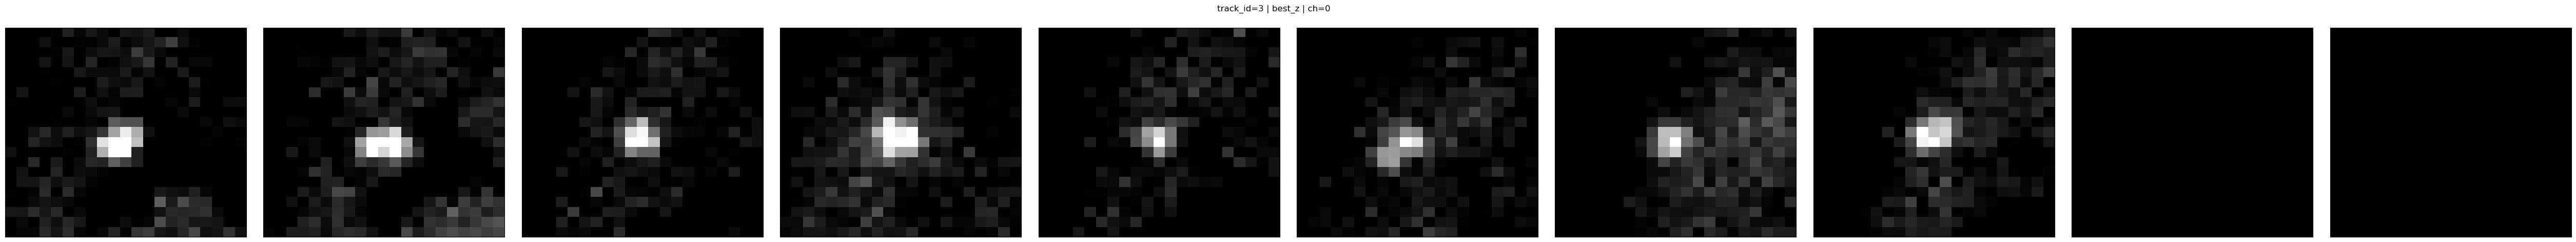

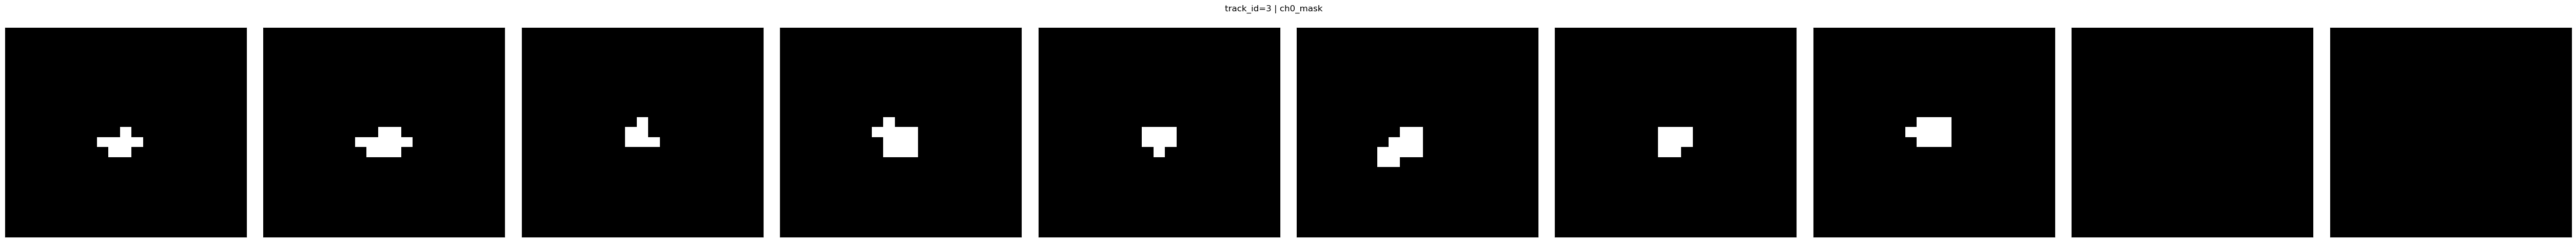

In [6]:
my_ta.tplot.plot_trackarray_crops(fov=0,track_ids=[3],t=(0,10,1),suppress_labels=True);
my_ta.tplot.plot_trackarray_crops(fov=0,track_ids=[3],t=(0,10,1),suppress_labels=True,layer="ch0_mask");

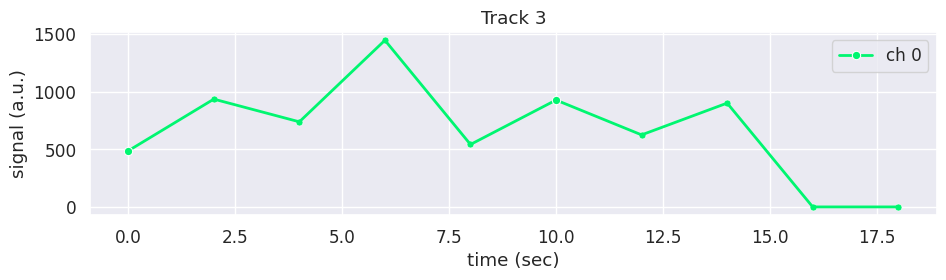

In [7]:
my_ta.tplot.plot_track_signal_traces(track_ids=[3],figsize=(9,3))

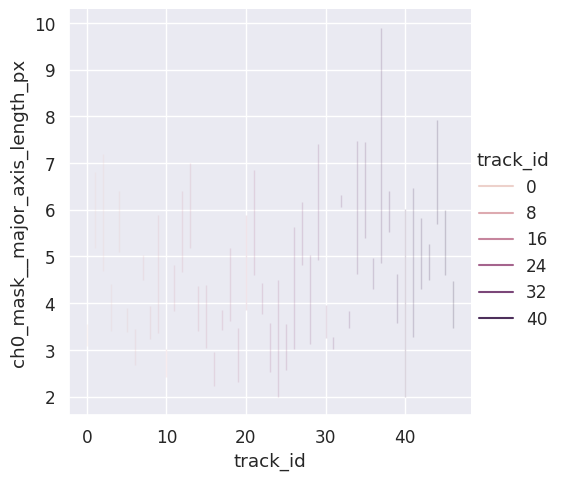

In [8]:
my_ta.plot.relplot(
    x="track_id", y="ch0_mask__major_axis_length_px",
    kind="line",
    hue="track_id",
    # col_wrap=4,
    #hue="ch",
    # estimator=None,          # prevents seaborn from averaging
    facet_kws={"sharey": True},
)


In [9]:
test = ca.concat([ca.concat(cas=[my_ta,my_ta],dim='exp'),ca.concat(cas=[my_ta,my_ta],dim='exp')],dim='rep')

In [ ]:
viewer, layers, ft = test.napari.manual_filter_montage(
    row="track_id",
    col="t",
    filter_name="stretchy",
    show=("best_z", "ch0_mask"),
    ch=0,
    colormaps={"ch0_mask":"magenta", "best_z":"green", "stretchy":"yellow"},
    output_dir=DATA_DIR,
    show_tile_text=True, # adds layer showin crop coords
)

/home/tstasevi/miniconda3/envs/croparray_env/lib/python3.10/site-packages/napari/layers/utils/style_encoding.py:257: RuntimeWarning: Applying the encoding failed. Using the safe fallback value instead.
  warnings.warn(
/home/tstasevi/miniconda3/envs/croparray_env/lib/python3.10/site-packages/napari/layers/utils/style_encoding.py:257: RuntimeWarning: Applying the encoding failed. Using the safe fallback value instead.
  warnings.warn(


DEBUG image_contrast: <class 'tuple'> (0.0, 99.5)


/home/tstasevi/miniconda3/envs/croparray_env/lib/python3.10/site-packages/napari/utils/colormaps/colormap.py:455: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(


In [11]:
viewer, layers = test.napari.montage_viewer(
    row="track_id",
    col="t",
    show=("best_z", "ch0_mask"),
    #ch=[0, 1, 2],  # RGB
    colormaps={"ch0_mask": "magenta","best_z": "green"},
    image_contrast=(0,100),
    show_tile_text=True,
)


/home/tstasevi/miniconda3/envs/croparray_env/lib/python3.10/site-packages/napari/layers/utils/style_encoding.py:257: RuntimeWarning: Applying the encoding failed. Using the safe fallback value instead.
  warnings.warn(
/home/tstasevi/miniconda3/envs/croparray_env/lib/python3.10/site-packages/napari/layers/utils/style_encoding.py:257: RuntimeWarning: Applying the encoding failed. Using the safe fallback value instead.
  warnings.warn(


DEBUG image_contrast: <class 'tuple'> (0, 100)


/home/tstasevi/miniconda3/envs/croparray_env/lib/python3.10/site-packages/napari/utils/colormaps/colormap.py:455: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(
